In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("ml_results_full_from_es.csv")
df["date"] = pd.to_datetime(df["date"])
df["price_change_numeric"] = (
    df["price_change"]
    .str.replace("%", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)
)

**Section 1: Number of Posts by Coin**

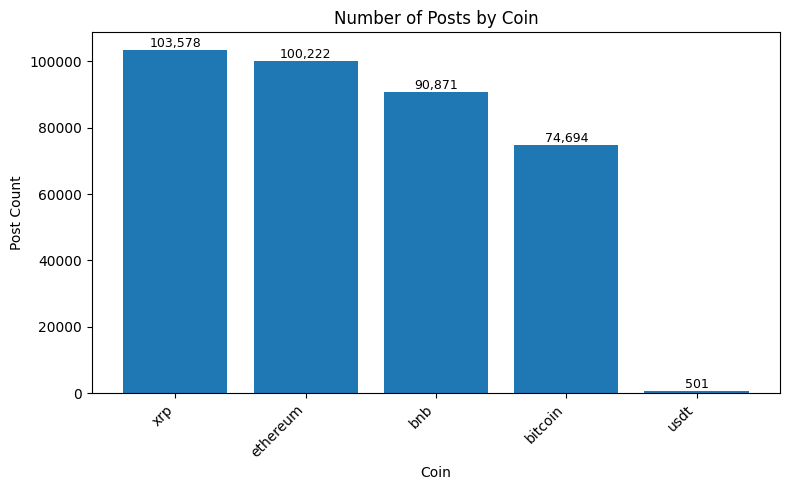

In [ ]:
coin_counts = df["coin"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(coin_counts.index, coin_counts.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Posts by Coin")
plt.xlabel("Coin")
plt.ylabel("Post Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Interestingly, Bitcoin did not have the highest number of posts in the dataset, despite being the most widely recognised cryptocurrency. Instead, XRP, Ethereum and BNB recorded higher post counts, with 103,578, 100,222, and 90,871 posts respectively. This was unexpected, as Bitcoin is often considered the most dominant cryptocurrency.


One possible explanation was post volume might reflect platform-specific discussion rather than overall market dominance. Since the data was collected from Mastodon and Bluesky, XRP, Ethereum, and BNB may have had more active communities on these platforms, while Bitcoin discussions may have been spread across other channels.

**Section 2: Average Price Change by Coin and Direction**

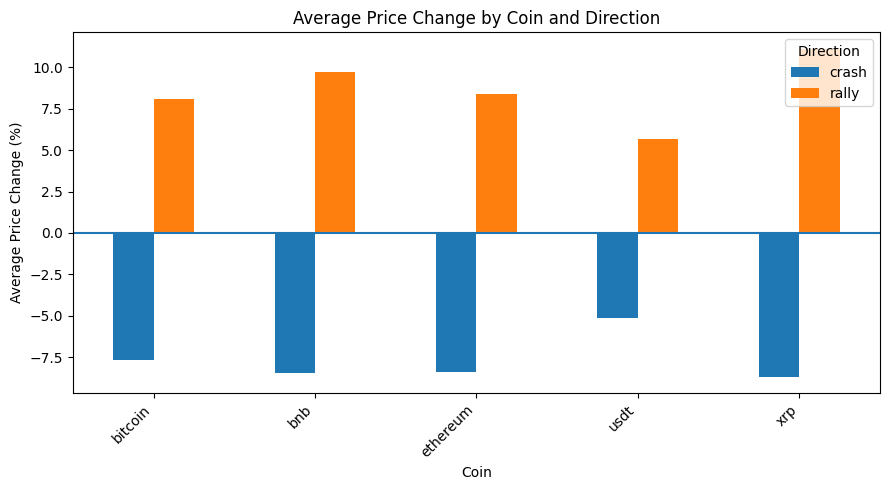

In [ ]:
df["price_change_numeric"] = (
    df["price_change"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)
)

avg_price_change = (
    df.groupby(["coin", "direction"])["price_change_numeric"]
      .mean()
      .unstack()
)

ax = avg_price_change.plot(kind="bar", figsize=(9, 5))

plt.title("Average Price Change by Coin and Direction")
plt.xlabel("Coin")
plt.ylabel("Average Price Change (%)")
plt.xticks(rotation=45, ha="right")
plt.axhline(0)
plt.legend(title="Direction")
plt.tight_layout()
plt.show()

Among the coins, XRP and BNB show the strongest average rally movements, with increases close to or obove 10%. For crash periods, XRP, BNB, Ethereum, and Bitcoin all show average declines of around 7%,while USDT shows a smaller decline.

Overall, the graph shows that XRP and BNB experience the largest average price swings. In contrast, USDT appears relatively more stable, which is expected as it is a stablecoin designed to maintain a more consistent value.

**Section 3: Rally vs Crash Post Count by Coin**

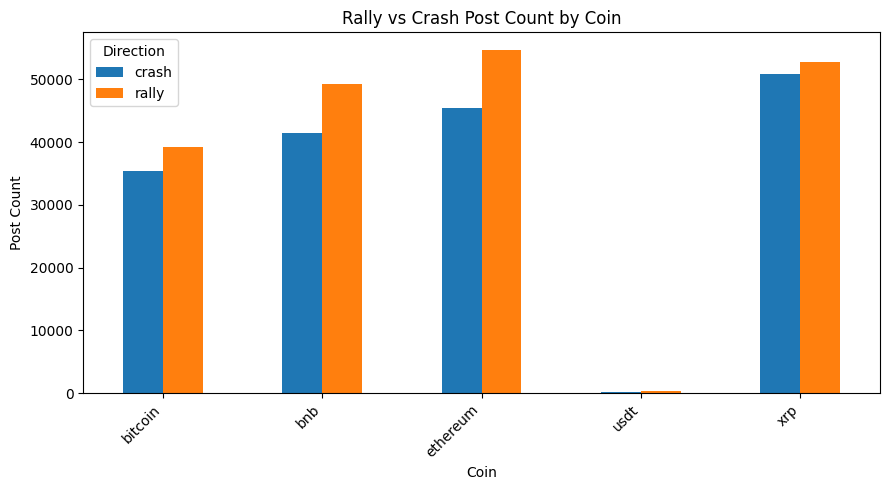

In [ ]:
direction_counts = (
    df.groupby(["coin", "direction"])
      .size()
      .unstack(fill_value=0)
)

ax = direction_counts.plot(kind="bar", figsize=(9, 5))

plt.title("Rally vs Crash Post Count by Coin")
plt.xlabel("Coin")
plt.ylabel("Post Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Direction")
plt.tight_layout()
plt.show()

The graph shows that there are more rally-related posts than crash-related posts for all five coins. This indicates that social media discussion is more active during price increases than during price decreases.

**Section 4: Monthly Spike Events for Ethereum, BNB, XRP, Bitcoin, USDT**

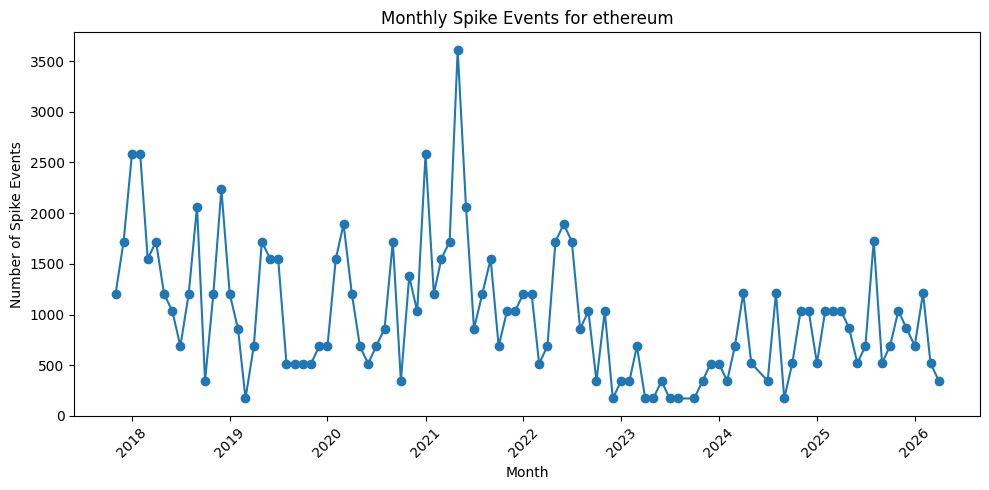

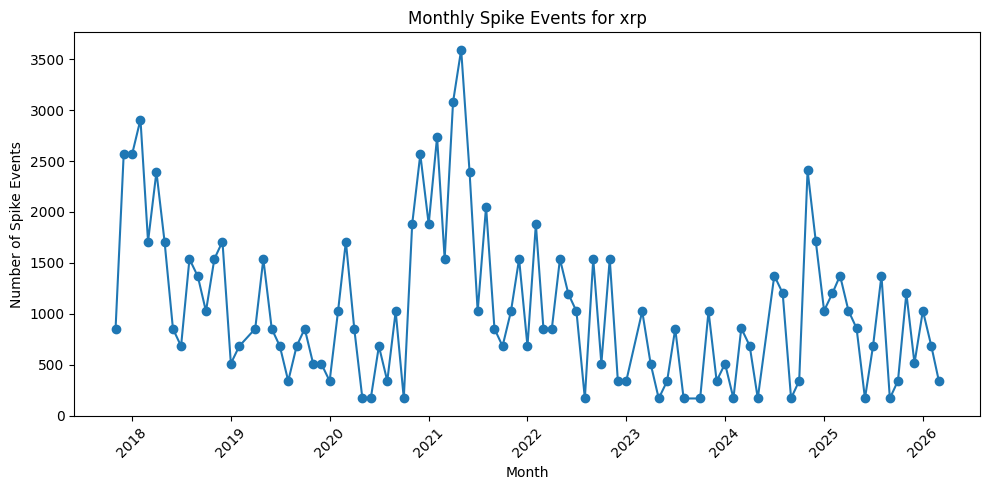

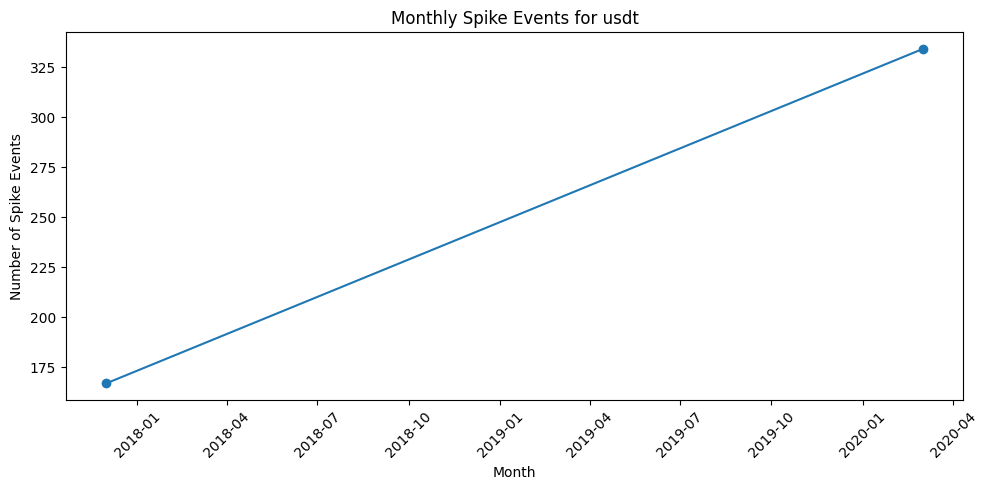

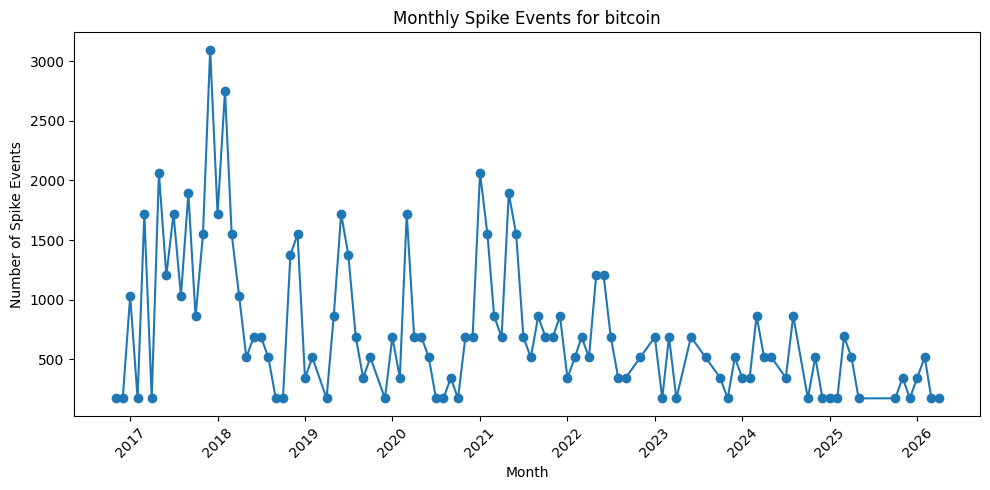

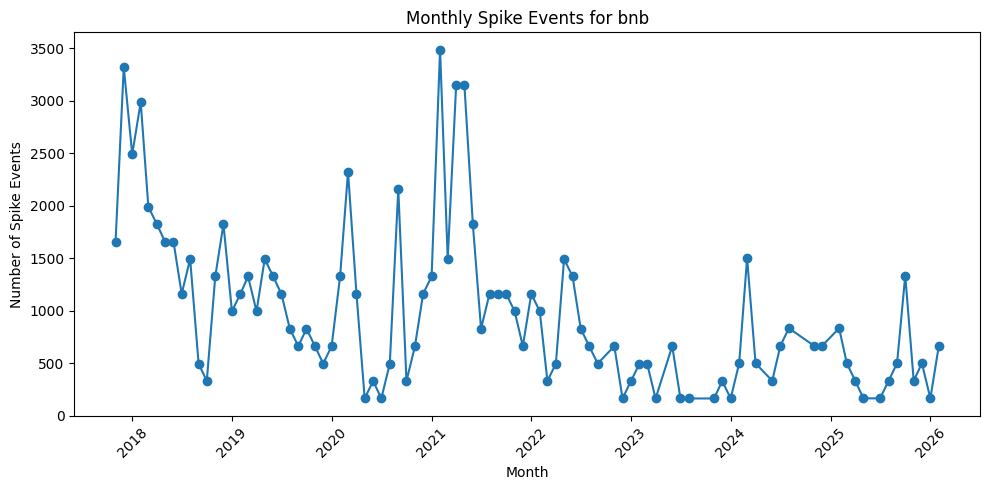

In [ ]:
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

monthly_events = (
    df.groupby(["month", "coin"])
    .size()
    .reset_index(name="event_count")
)

for coin in df["coin"].unique():
    coin_df = monthly_events[monthly_events["coin"] == coin]

    plt.figure(figsize=(10, 5))
    plt.plot(coin_df["month"], coin_df["event_count"], marker="o")

    plt.xlabel("Month")
    plt.ylabel("Number of Spike Events")
    plt.title(f"Monthly Spike Events for {coin}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"Graph6_Monthly_Spike_Events_{coin}.png", dpi=300, bbox_inches="tight")
    plt.show()

Monthly spike-event trends show that spike activity was unevenly distributed over time. For major coins such as Bitcoin, Ethereum, XRP, and BNB, spike events were more concentrated around earlier high-activity market periods, particularly around 2017–2018 and 2021. After 2022, the number of monthly spike events generally appears lower and less volatile. This suggests that market attention and extreme price movements were clustered in specific periods.



The high sharp price change activity around 2022 may also reflect the wider crypto market crash. Events such as the Terra-Luna collapse and the FTX collapse contributed to significant market instability. In contrast, USDT shows fewer spike events, which is expected because it is a stablecoin. However, this result should be interpreted carefully, as the USDT pattern appears to be based on limited observations, with only a small number of spike-event points available.

In [ ]:
df = pd.read_csv("ml_daily_sentiment.csv")
df["date"] = pd.to_datetime(df["date"])
df_clean = df[df["date"].dt.year <= 2026].copy()


**Average sentiment over time**

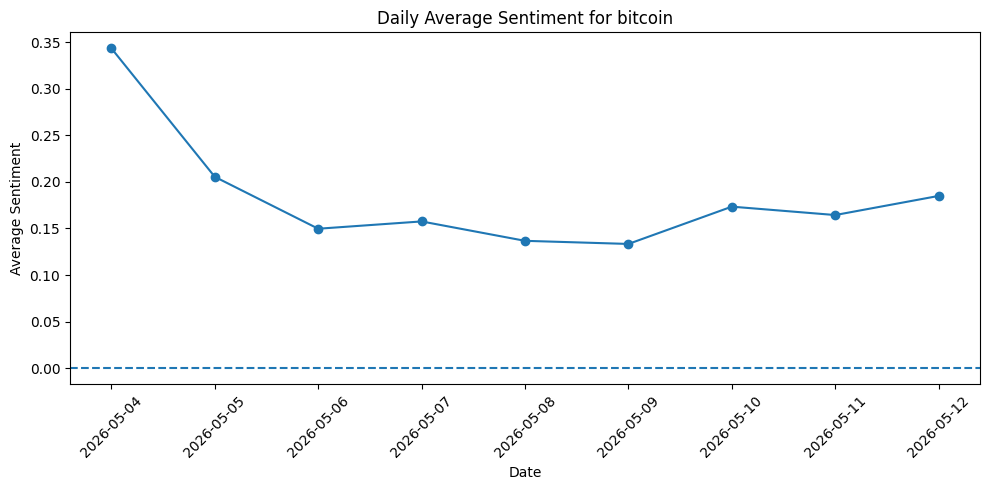

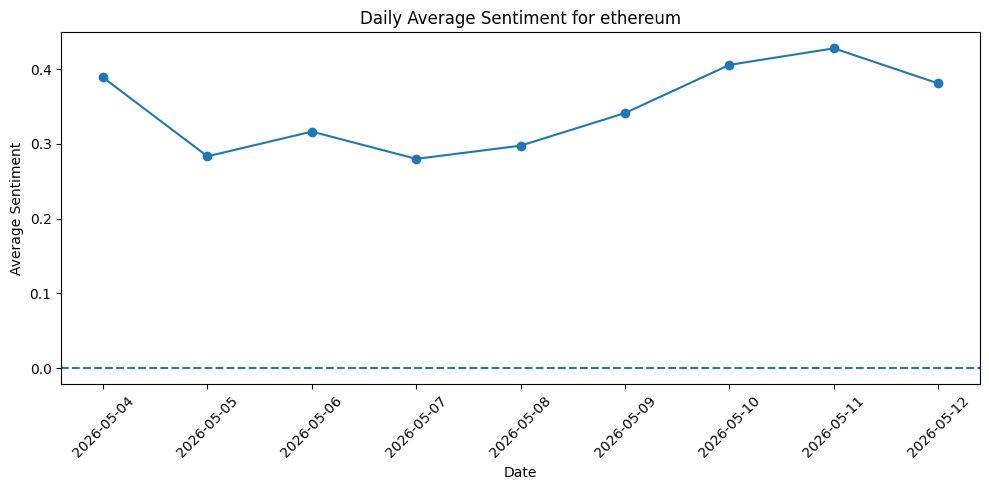

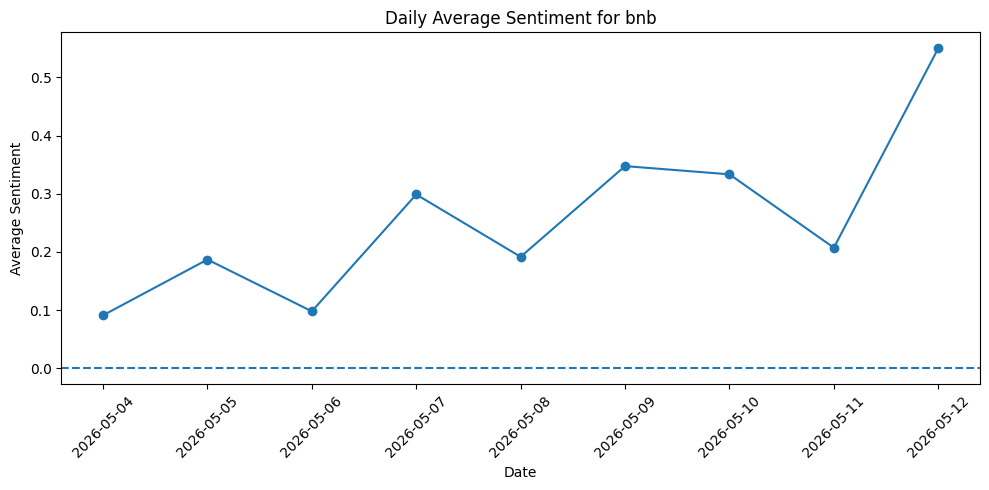

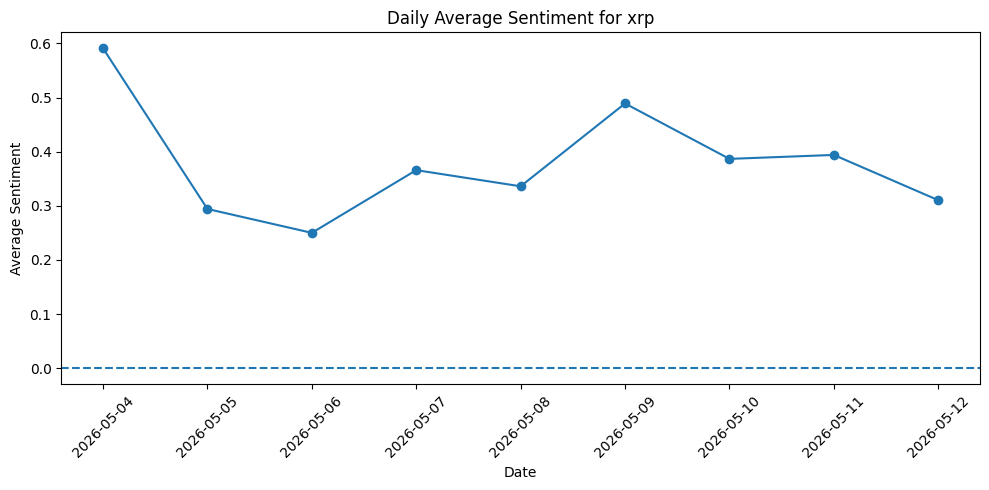

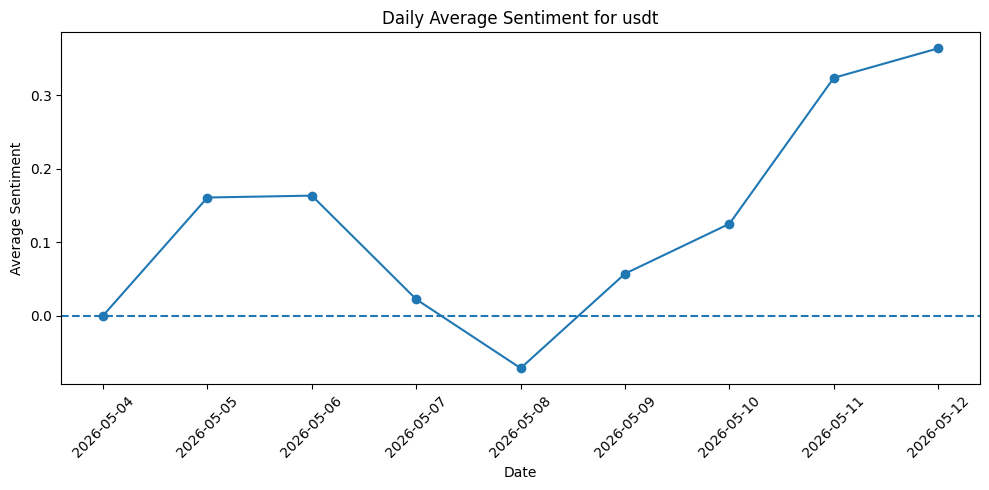

In [ ]:
for coin in df_clean["coin"].unique():
    coin_df = df_clean[df_clean["coin"] == coin].copy()
    coin_df = coin_df.sort_values("date")

    plt.figure(figsize=(10, 5))
    plt.plot(coin_df["date"], coin_df["avg_sentiment"], marker="o")
    plt.axhline(0, linestyle="--")

    plt.title(f"Daily Average Sentiment for {coin}")
    plt.xlabel("Date")
    plt.ylabel("Average Sentiment")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

From the graphs, Bitcoin shows a decline in sentiment from the first day, but then remains relatively stable at a mildly positive level. Ethereum and XRP maintain consistently positive sentiment throughout the period, with Ethereum increasing toward the later dates before slightly falling. BNB shows more fluctuation but ends with the highest sentiment value among the coins. USDT is the most volatile, briefly dropping below zero before rising strongly toward the end of the period.

Overall, the daily average sentiment graphs show that sentiment is generally positive across all coins, suggesting that over the observed period, social media discussions was more bullish/positive than bearish overall.

**Post volume vs sentiment: When there are more posts, is sentiment more positive or negative?**

bitcoin: post count vs average sentiment correlation = -0.0142


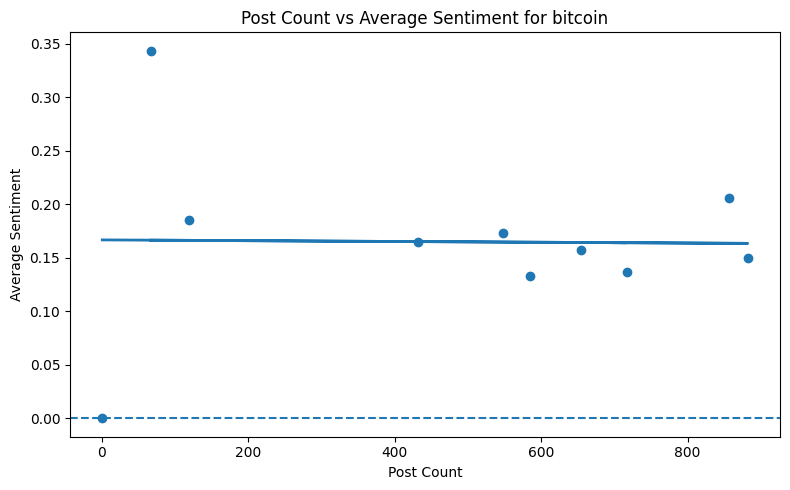

ethereum: post count vs average sentiment correlation = -0.6473


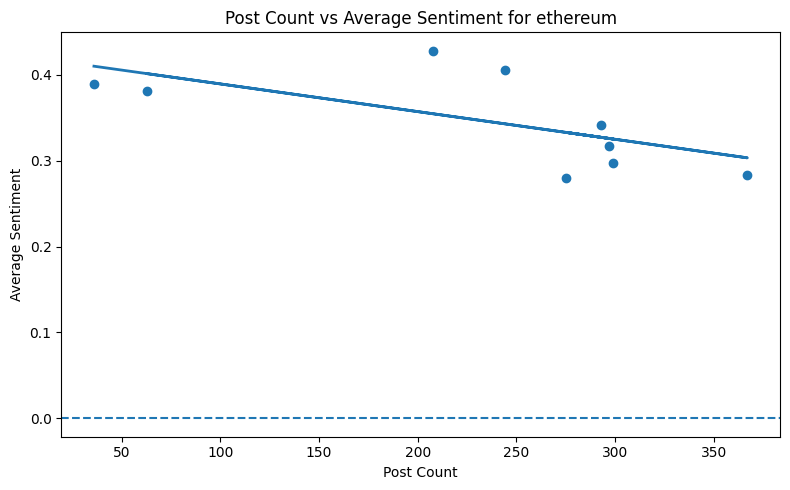

bnb: post count vs average sentiment correlation = -0.4983


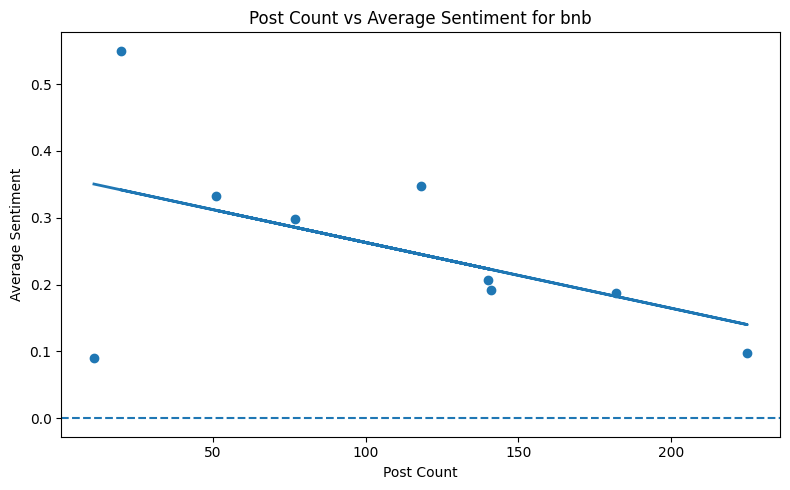

xrp: post count vs average sentiment correlation = -0.4931


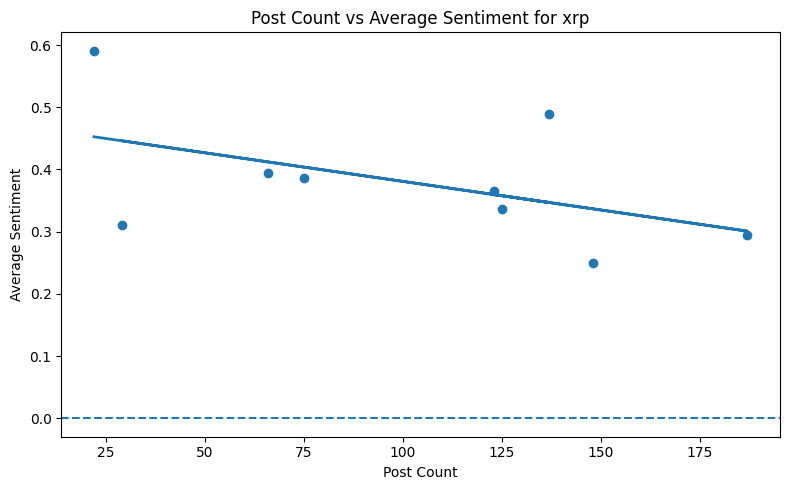

usdt: post count vs average sentiment correlation = 0.0307


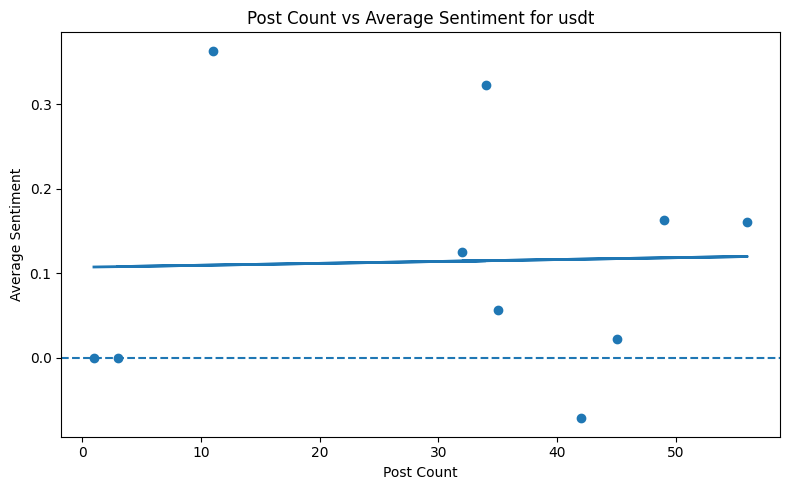

In [ ]:
for coin in df["coin"].unique():
    coin_df = df[df["coin"] == coin]

    corr = coin_df["post_count"].corr(coin_df["avg_sentiment"])
    print(f"{coin}: post count vs average sentiment correlation = {corr:.4f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(coin_df["post_count"], coin_df["avg_sentiment"])

    # Regression line
    x = coin_df["post_count"]
    y = coin_df["avg_sentiment"]

    m, b = np.polyfit(x, y, 1)   # m = slope, b = intercept
    plt.plot(x, m * x + b, linewidth=2)

    plt.xlabel("Post Count")
    plt.ylabel("Average Sentiment")
    plt.title(f"Post Count vs Average Sentiment for {coin}")
    plt.axhline(0, linestyle="--")
    plt.tight_layout()
    plt.show()

The correlation results show that higher post volume is not always associated with more positive sentiment. It is shown that for Bitcoin and USDT, the correlations are close to zero, indicating little to no relationship between the number of posts and average sentiment. However, in contrast, Ethereum shows a moderately strong negative correlation at -0.6473, while BNB and XRP showed moderate negative correlations at -0.4983 and -0.4931 respectively. One possible interpretation of why increased discussion may be associated with more negative sentiment is that the coins receive more attention during periods or uncertainty or concern. However, as correlation does not imply causation, theese results should be interpreted as associations rather than proof that higher post volume causes more negative sentiment.

**Section 5: Sentiment Composition**

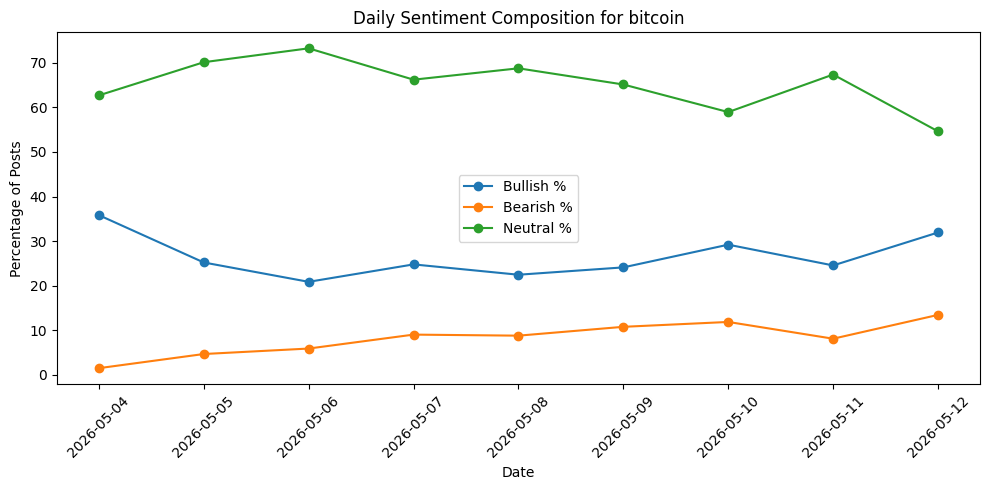

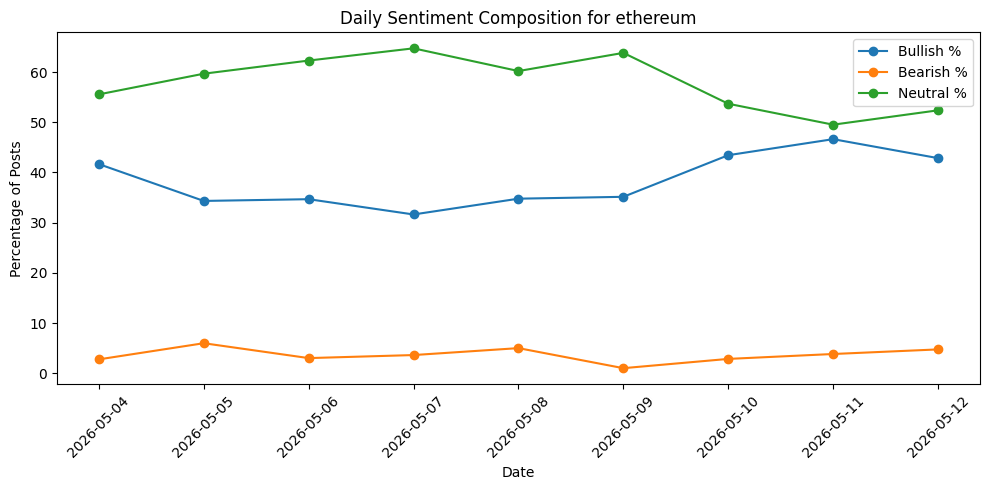

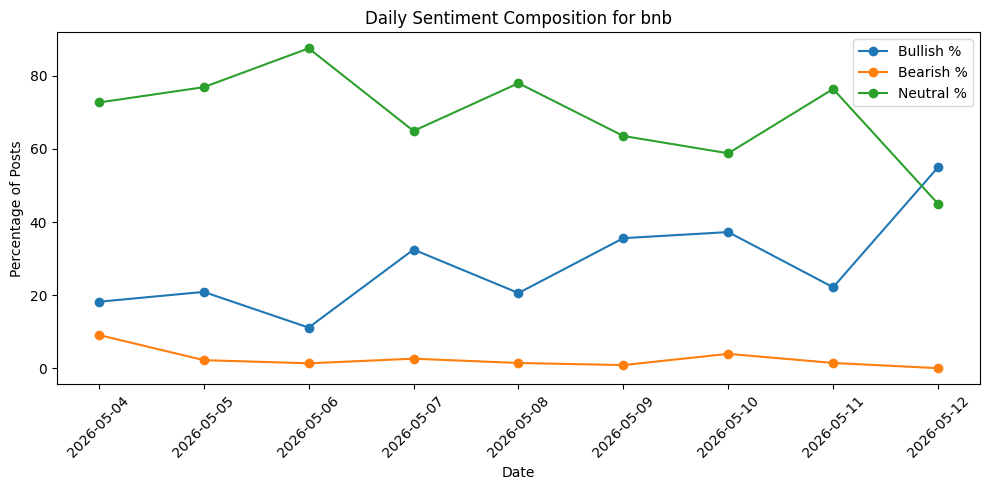

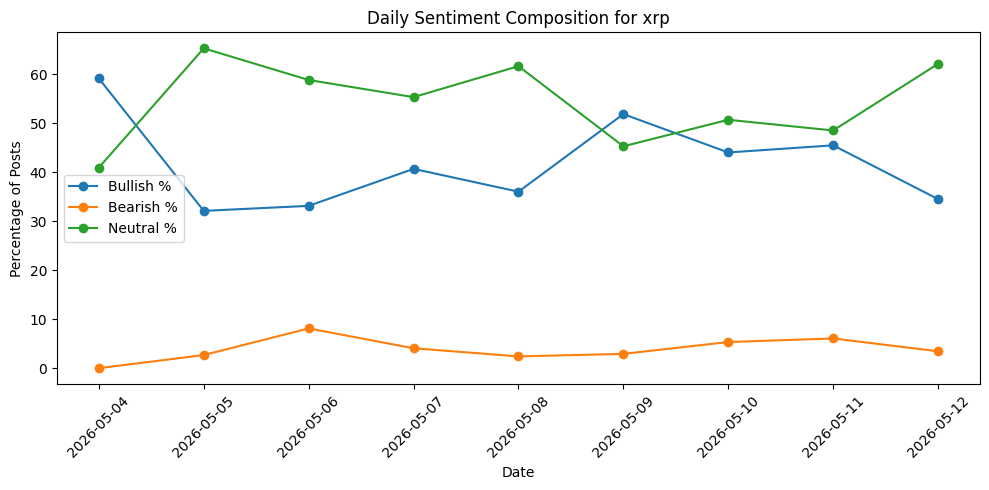

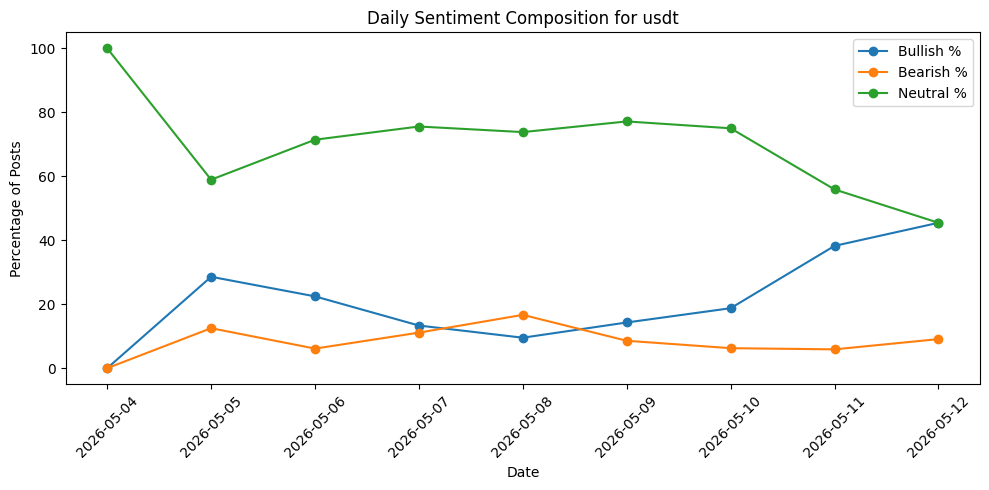

In [ ]:
df_clean["bullish_pct"] = df_clean["bullish_count"] / df_clean["post_count"] * 100
df_clean["bearish_pct"] = df_clean["bearish_count"] / df_clean["post_count"] * 100
df_clean["neutral_pct"] = df_clean["neutral_count"] / df_clean["post_count"] * 100
for coin in df_clean["coin"].unique():
    coin_df = df_clean[df_clean["coin"] == coin]

    plt.figure(figsize=(10, 5))
    plt.plot(coin_df["date"], coin_df["bullish_pct"], marker="o", label="Bullish %")
    plt.plot(coin_df["date"], coin_df["bearish_pct"], marker="o", label="Bearish %")
    plt.plot(coin_df["date"], coin_df["neutral_pct"], marker="o", label="Neutral %")

    plt.xlabel("Date")
    plt.ylabel("Percentage of Posts")
    plt.title(f"Daily Sentiment Composition for {coin}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


The sentiment composition graphs show that neutral sentiment dominate across the five cryptocurrencies, with bearish seniment remains consistently low across the five cryptocurrencies.


For coins like Ethereum, BNB, XRP, and USDT, the posts are mostly neutral on most days. Bullish sentiment is also present, especially for XRP and BNB on some dates, but they stay relatively lower than neutral sentiments.

Overall, the sentiment across the five cryptocurrency posts are generally neutral to positive.

In [ ]:
df = pd.read_csv("ml_narratives.csv")

df["active_start_date"] = pd.to_datetime(df["active_start_date"])
df["active_end_date"] = pd.to_datetime(df["active_end_date"])
df.head()

df.columns

Index(['price_regime', 'topic_id', 'topic_label', 'post_count',
       'percentage_within_price_regime', 'active_start_date',
       'active_end_date', 'active_duration_days', 'coin'],
      dtype='object')

**Section 6: Top Narratives Overall**

In [ ]:
dominant_topics = (
    df
    .sort_values(
        ["coin", "price_regime", "percentage_within_price_regime"],
        ascending=[True, True, False]
    )
    .groupby(["coin", "price_regime"])
    .head(1)
    .reset_index(drop=True)
)

dominant_topics

,price_regime,topic_id,topic_label,post_count,percentage_within_price_regime,active_start_date,active_end_date,active_duration_days,coin
0,bear/decrease,2,"24h, later, save later, save, watching",328,59.528131,2026-05-11,2026-05-12,2,bitcoin
1,bull/increase,2,"24h, later, save later, save, watching",2760,64.037123,2026-05-04,2026-05-10,7,bitcoin
2,bull/increase,2,"live trump, moves live, massive moves, catchin...",460,57.142857,2026-05-04,2026-05-10,7,bnb
3,neutral/flat,2,"live trump, moves live, massive moves, catchin...",81,50.625000,2026-05-11,2026-05-12,2,bnb
4,bear/decrease,3,"xrp, investment, memecoin, notspam post, xrp n...",139,51.291513,2026-05-11,2026-05-12,2,ethereum
5,neutral/flat,3,"xrp, investment, memecoin, notspam post, xrp n...",899,49.641082,2026-05-04,2026-05-10,7,ethereum
6,neutral/flat,2,"million, 30, days, 30 days, tron",216,70.358306,2026-05-04,2026-05-12,9,usdt
7,bear/decrease,3,"eth, sol, bnb, ada, 001",74,77.894737,2026-05-11,2026-05-12,2,xrp
8,bull/increase,3,"eth, sol, bnb, ada, 001",612,74.908201,2026-05-04,2026-05-10,7,xrp


**Interpretation of the dominant topic (highest percentage) per coin:**

**Bitcoin**:
- "24h, later, save later, watching": Market monitoring/watchlist behaviour

**Ethereum**:
- "investment, memecoin, xrp": General crypto investment discussion, does not seem related to Ethereum

**BNB**:
- "live, trump, massive moves": Hype-driven trading updates

**XRP**:
- "eth, sol, bnb, ada": Broad coin discussion

**USDT**:
- "million, 30 days, tron": USDT/TRON transaction activity


**Section 7: Narrative Distribution Across Ethereum, Bitcoin, BNB, XRP, USDT**

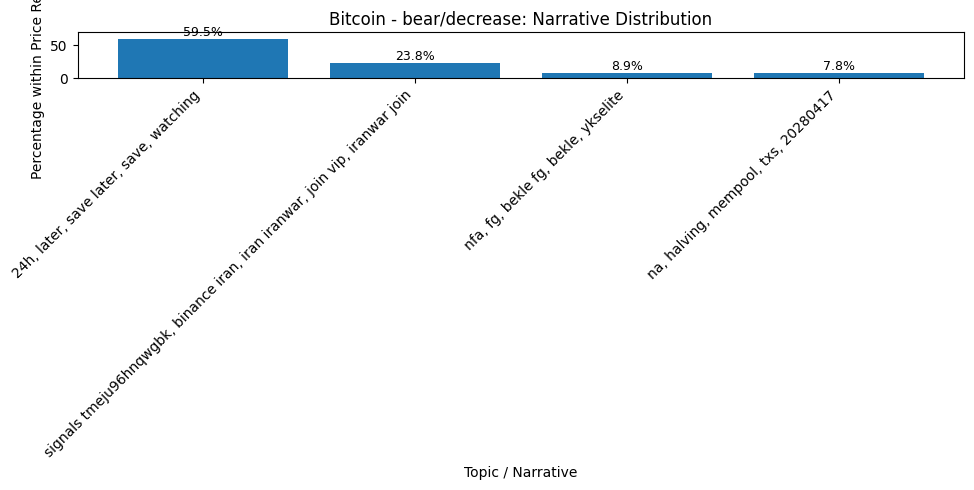

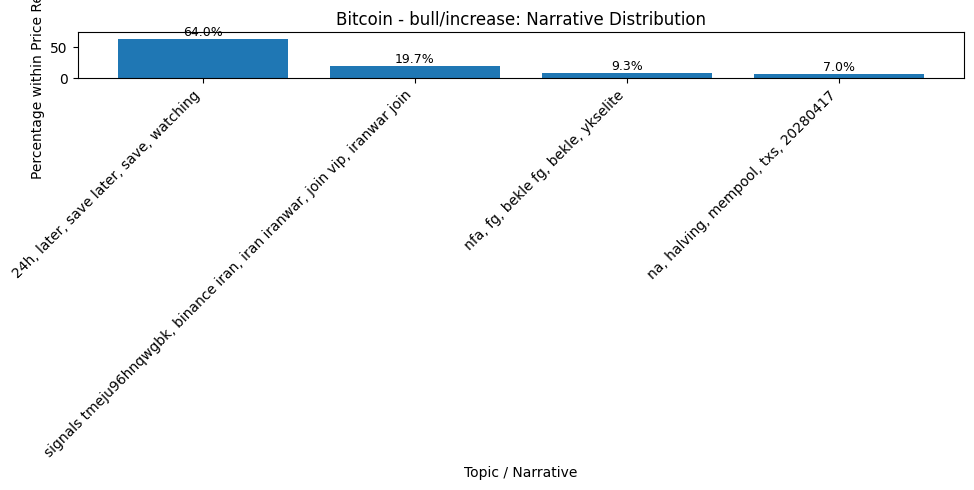

/tmp/ipykernel_941/2690084795.py:47: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


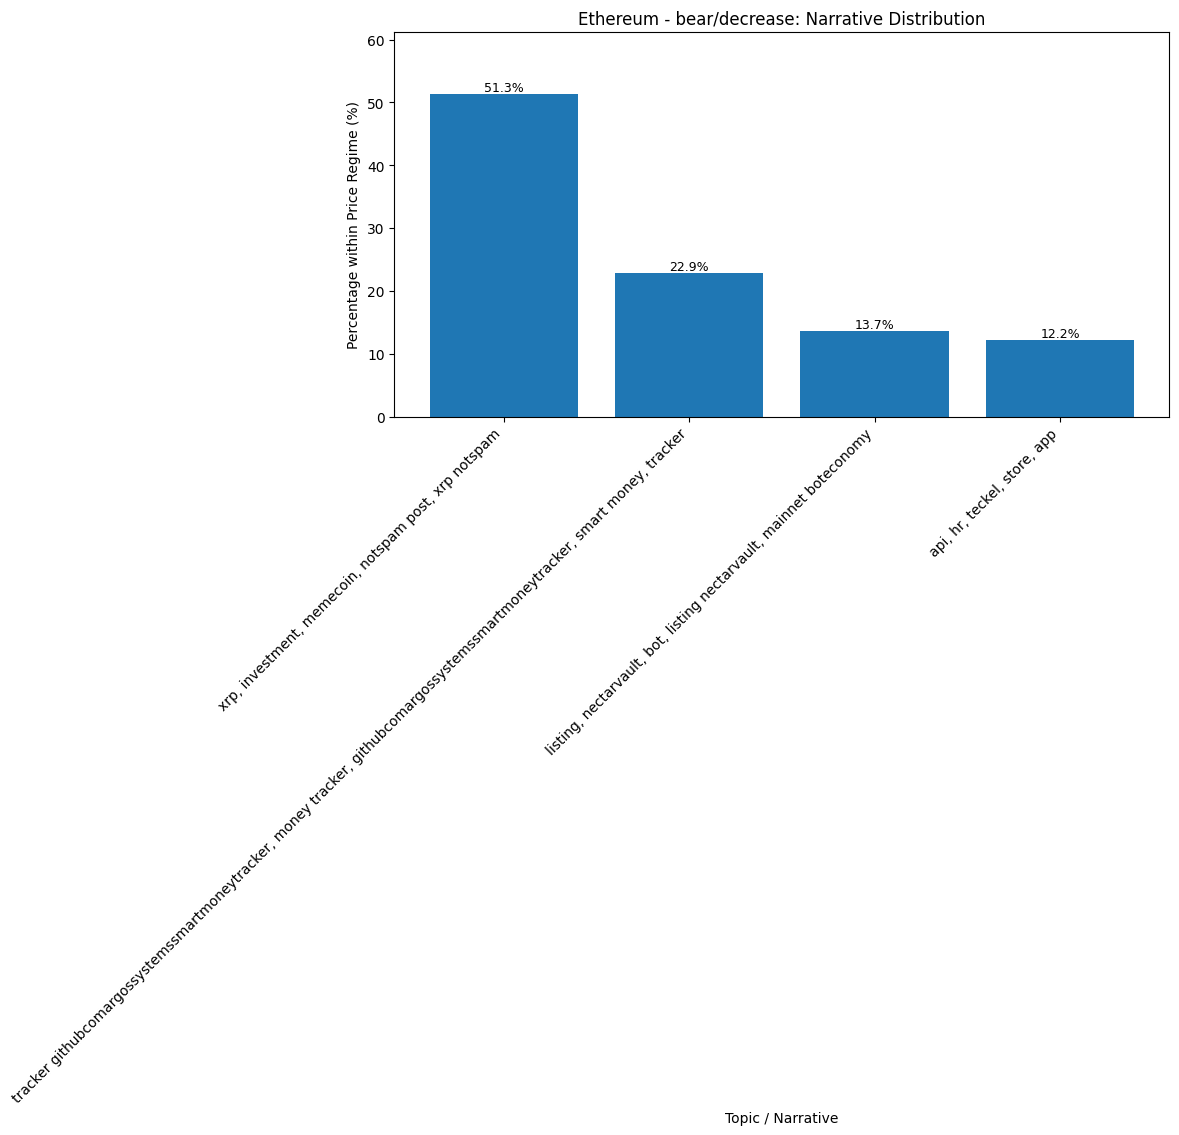

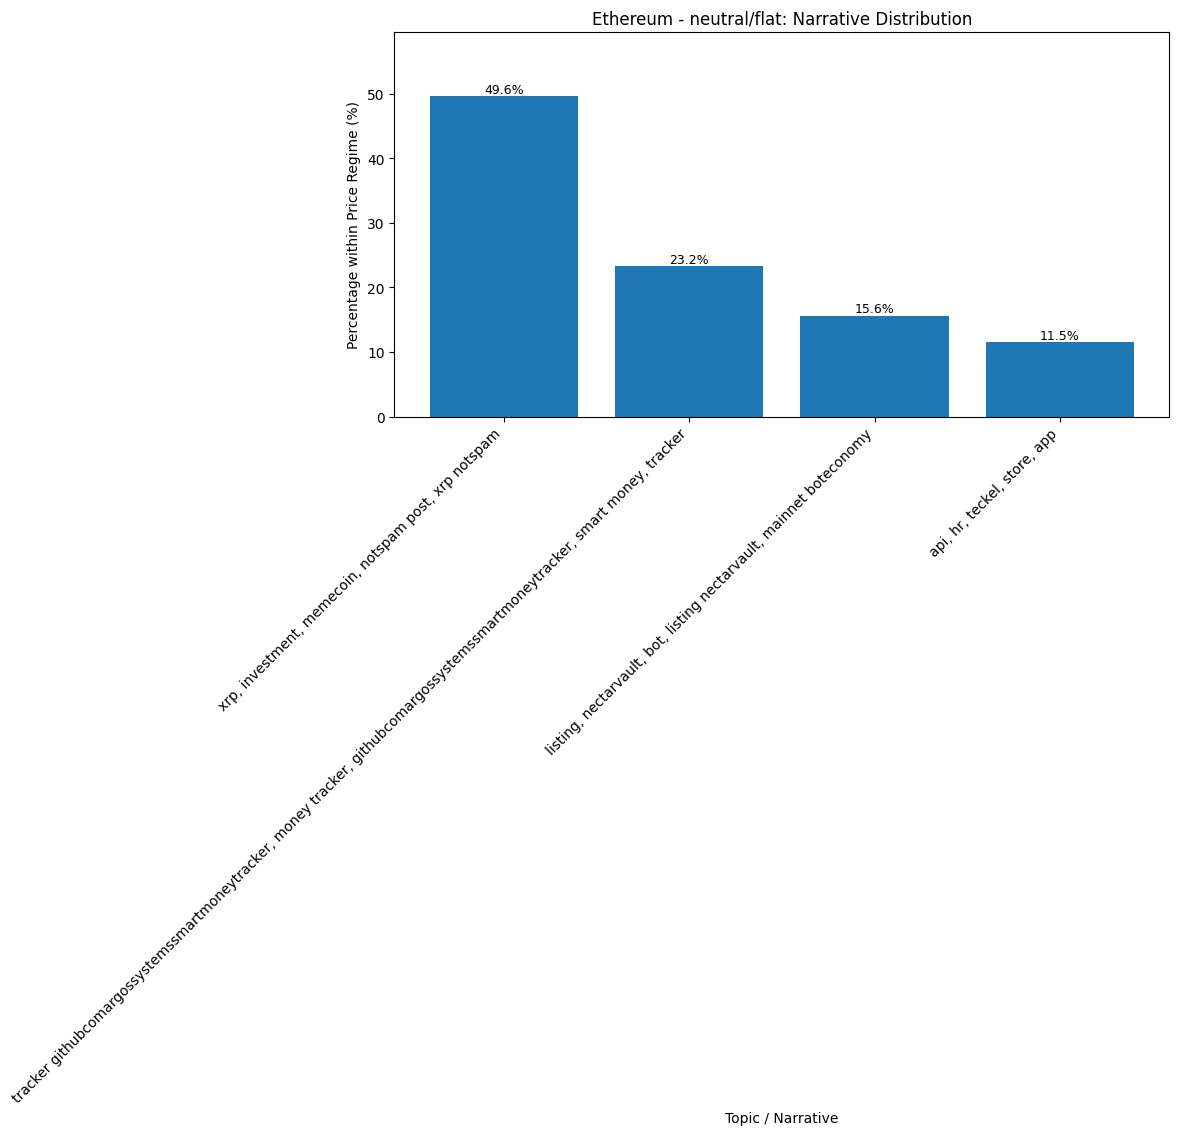

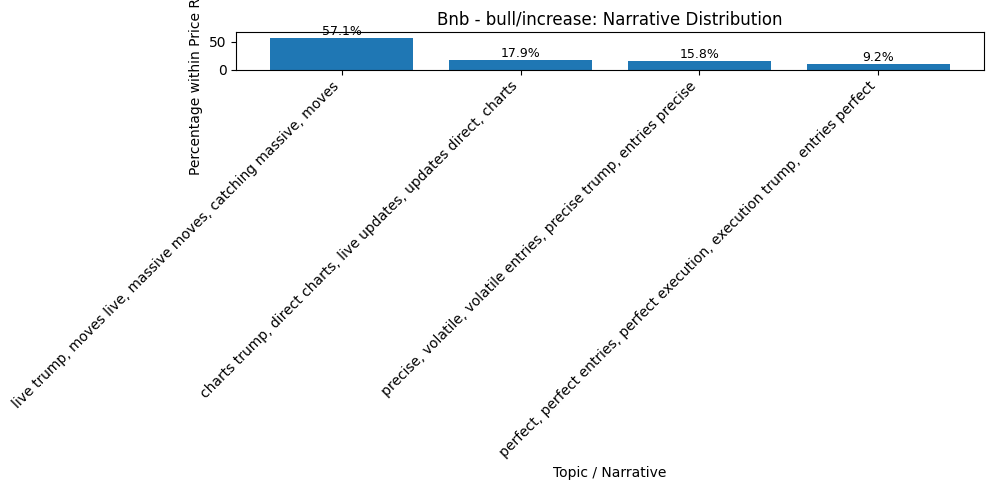

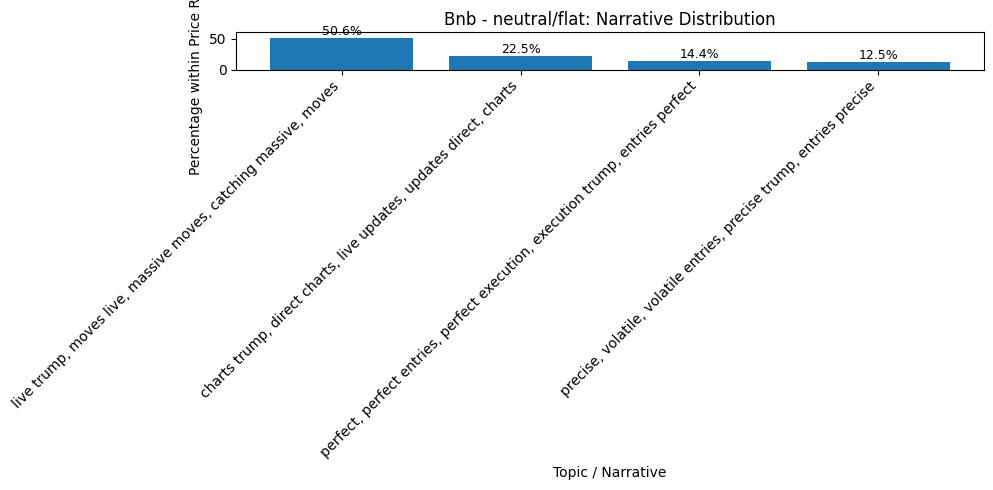

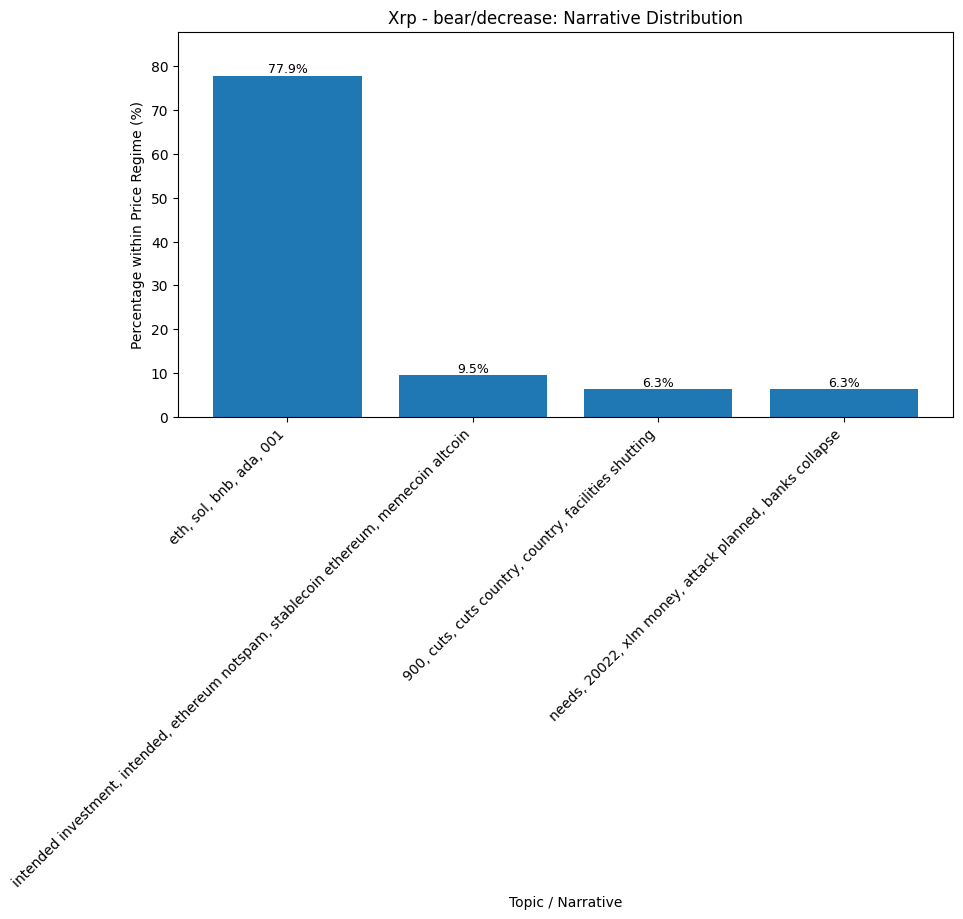

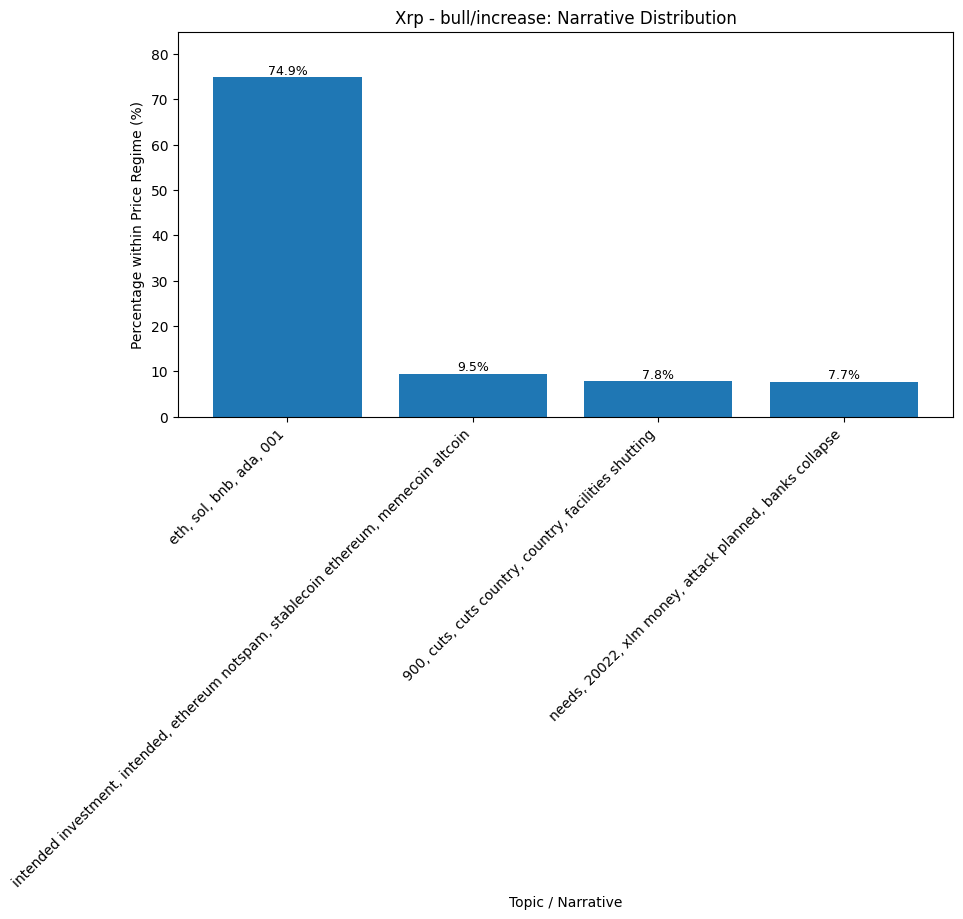

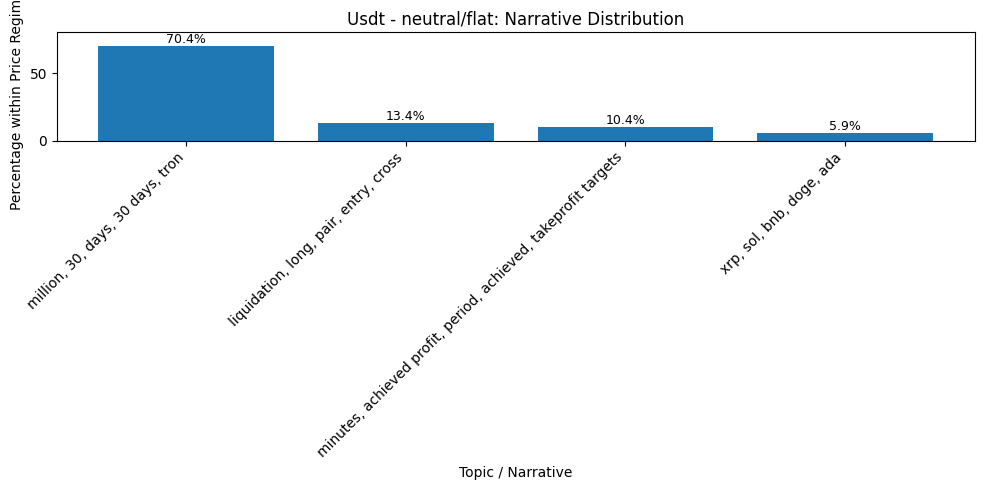

In [ ]:
df["percentage_within_price_regime"] = (
    df["post_count"] /
    df.groupby(["coin", "price_regime"])["post_count"].transform("sum")
    * 100
)

regime_order = ["bear/decrease", "bull/increase", "neutral/flat"]

for coin in df["coin"].unique():
    for regime in regime_order:

        plot_df = df[
            (df["coin"] == coin) &
            (df["price_regime"] == regime)
        ].copy()

        # Skip if no data
        if plot_df.empty:
            continue

        plot_df = plot_df.sort_values("percentage_within_price_regime", ascending=False)

        plt.figure(figsize=(10, 5))

        bars = plt.bar(
            plot_df["topic_label"],
            plot_df["percentage_within_price_regime"]
        )

        # Add percentage labels inside/on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.title(f"{coin.capitalize()} - {regime}: Narrative Distribution")
        plt.xlabel("Topic / Narrative")
        plt.ylabel("Percentage within Price Regime (%)")
        plt.xticks(rotation=45, ha="right")
        plt.ylim(0, plot_df["percentage_within_price_regime"].max() + 10)
        plt.tight_layout()
        plt.show()

Based on the plotted narrative distributions, there appears to be little difference in the dominant narratives across bear/decrease, bull/increase, and neutral/flat price regimes.
The same topics remain dominant across different price regimes. For example, Bitcoin's leading topic is around 59.5% in bear/decrease and 64% in bull/increase, while XRP's dominant topic is at 77.9% in bear/decrease and 74.9% in bull/increase.

Overall, the changes are mostly small percentages differences, not major changes in topic ranking. This suggests that the narratives are more coin-specific rather than price-regime specific.